# What Explains Winning in the NBA?
### A Statistical Analysis of Team Season Ratings (NBA Statistics API)

In [99]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# brings in the exact NBA stats machine we want
from nba_api.stats.endpoints import leaguedashteamstats

from urllib3.util.retry import Retry
from requests.adapters import HTTPAdapter
from nba_api.stats.library.http import NBAStatsHTTP

In [100]:
retry_strategy = Retry(
    total=8,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
    backoff_factor=1.5,
)

adapter = HTTPAdapter(max_retries=retry_strategy)

# nba_api uses requests under the hood; this patches its session
NBAStatsHTTP()._session.mount("https://", adapter)
NBAStatsHTTP()._session.mount("http://", adapter)

In [101]:
# fetch team-level advanced stats for a given season
def fetch_team_stats(season_end_year: int) -> pd.DataFrame:
    """
    season_end_year: 2024 mans 2023-24 season.
    Returns team-level advanced stats for regular season.
    """
    season = f"{season_end_year-1}-{str(season_end_year)[-2:]}"  # e.g. "2023-24"
    
    resp = leaguedashteamstats.LeagueDashTeamStats(
        season = season,
        season_type_all_star = "Regular Season",
        measure_type_detailed_defense = "Advanced",
        per_mode_detailed = "PerGame",
        timeout = 60   # wait up to 60s to collect the data
    )

    df = resp.get_data_frames()[0].copy()
    df["Season"] = season_end_year
    
    # compute win percentage
    df["WinPct"] = df["W"] / (df["W"] + df["L"])
    
    # converts to percentage form with 1 decimal and adds a gaurd against division by zero
    df["WinPct"] = np.where(
        (df["W"] + df["L"]) > 0,
        (df["W"] / (df["W"] + df["L"]) * 100).round(1),
         np.nan
    )
    return df

In [102]:
# pulls multiple seasons (2015 - 2024)
seasons = list(range(2015,2025)) # 2014..2024
frames = []

for y in seasons:
    frames.append(fetch_team_stats(y))
    time.sleep(2.5) # polite delay
    
df = pd.concat(frames, ignore_index = True)

In [103]:
# save the dataset
df.to_csv("data/nba_team_advanced_2015_2024.csv", index = False)

## Exploratory Data Analysis
Exploratory scatter plots show a strong positive relationship between Net Rating and win percentage. Shooting efficiency metrics exhibit a moderate association with winning, while pace shows little to no relationship. These patterns motivate the subsequent correlation and regression analysis.

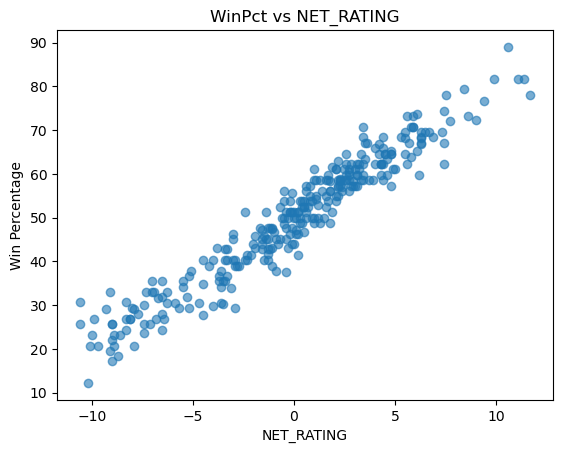

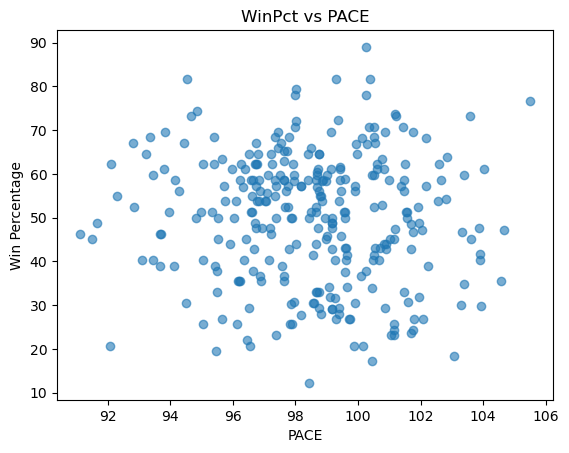

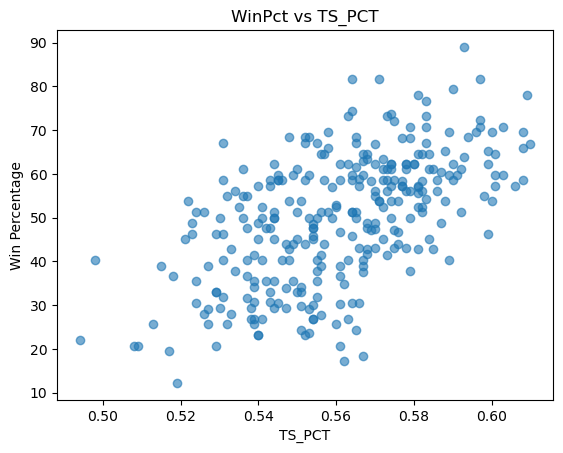

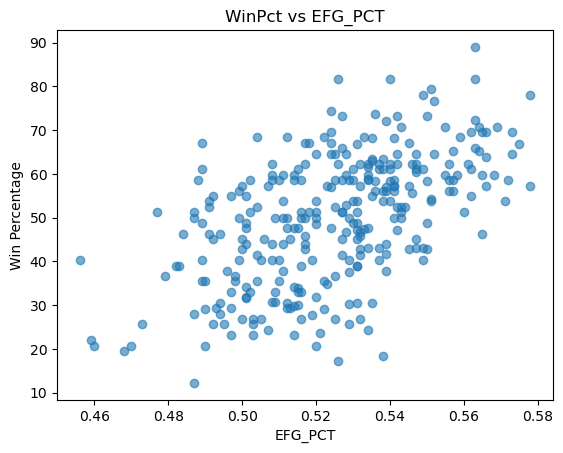

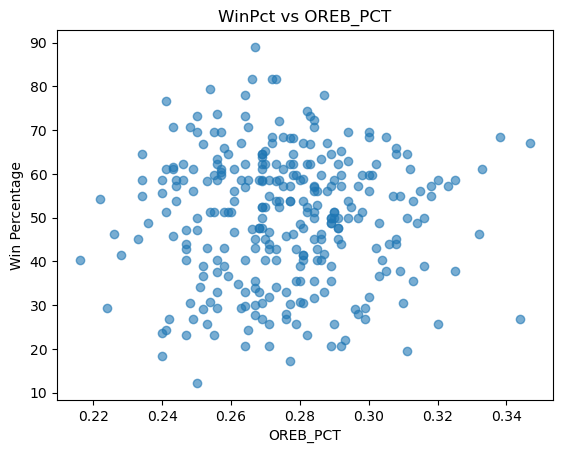

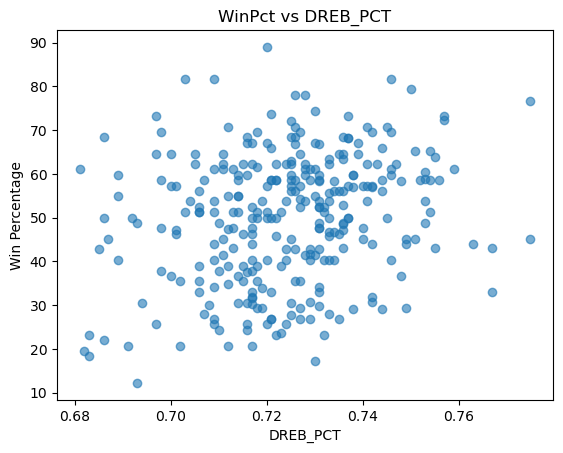

In [104]:
# exploratory data analysis
for col in features:
    plt.figure()
    plt.scatter(df[col], df["WinPct"], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("Win Percentage")
    plt.title(f"WinPct vs {col}")

    # save plots
    if col == "NET_RATING":
        plt.savefig("figures/winpct_vs_net_rating.png", dpi = 200)
    elif col == "TS_PCT":
        plt.savefig("figures/winpct_vs_ts_pct.png", dpi = 200)
        
    plt.show()

In [105]:
# correlation analysis
corr = df[["WinPct"] + features].corr()["WinPct"].sort_values(ascending = False)

corr

WinPct        1.000000
NET_RATING    0.963234
TS_PCT        0.572413
EFG_PCT       0.553506
DREB_PCT      0.233215
OREB_PCT      0.016338
PACE         -0.064835
Name: WinPct, dtype: float64

In [106]:
# baseline regression: WinPct ~ Net Rating
X = df[["NET_RATING"]]
y = df["WinPct"]

X = sm.add_constant(X)

model_1 = sm.OLS(y, X).fit()

model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 WinPct   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     3831.
Date:                Sat, 03 Jan 2026   Prob (F-statistic):          3.85e-172
Time:                        14:34:13   Log-Likelihood:                -837.23
No. Observations:                 300   AIC:                             1678.
Df Residuals:                     298   BIC:                             1686.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.9753      0.228    218.816      0.000      49.526      50.425
NET_RATING     2.9962      0.048     61.891      0.000       2.901       3.092
==============================================================================
Omnibus:                        1.686   Durbin-Watson:                   1.927
Prob(Omnibus):                  0.430   Jarque-Bera (JB):                1.406
Skew:                          -0.108   Prob(JB):                        0.495
Kurtosis:                       3.256   Cond. No.                         4.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Robustness Check
This model tests whether shooting effiiency or rebounding add explanatory power once Net Rating is held constant.

In [107]:
# check if TS% and EFG% are basically the same
df[["TS_PCT", "EFG_PCT"]].corr()

,TS_PCT,EFG_PCT
TS_PCT,1.000000,0.981934
EFG_PCT,0.981934,1.000000


In [108]:
# run the regression on the updated model
# define the X2 (predictor) and the Y (response)
X2 = df[["NET_RATING", "TS_PCT", "DREB_PCT"]]
y = df["WinPct"]

# add intercept (baseline win percentage)
X2 = sm.add_constant(X2)
model_2 = sm.OLS(y, X2).fit()

model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 WinPct   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     1274.
Date:                Sat, 03 Jan 2026   Prob (F-statistic):          8.13e-169
Time:                        14:34:13   Log-Likelihood:                -836.63
No. Observations:                 300   AIC:                             1681.
Df Residuals:                     296   BIC:                             1696.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.4525     12.266      4.032      0.000      25.314      73.591
NET_RATING     2.9722      0.061     48.666      0.000       2.852       3.092
TS_PCT        11.4215     12.596      0.907      0.365     -13.368      36.211
DREB_PCT      -8.1217     13.667     -0.594      0.553     -35.018      18.775
==============================================================================
Omnibus:                        1.870   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.393   Jarque-Bera (JB):                1.602
Skew:                          -0.110   Prob(JB):                        0.449
Kurtosis:                       3.282   Cond. No.                         376.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Conclusion
A multivariate regression including Net Rating, True Shooting Percentage, and Defensive Rebound Percentage shows that Net Rating remains the dominant and statistically significant predictor of team win percentage. Once Net Rating is controlled for, neither shooting efficiency nor rebounding provides additional explanatory power. This suggests that Net Rating effectively aggregates the key componenets of team performance relevent to winning.